# Borrower Optionality Score

**What this is**: an application of established option-theoretic mortgage valuation (Kau, Keenan, Muller, Epperson et al.) -- a mortgage is a bundle of two options the borrower holds: a **put option to default** (in the money when equity goes negative) and a **call option to prepay/refinance** (in the money when market rates drop below the borrower's rate). This notebook computes both option "moneyness" values per loan and combines them into a business-facing score: *not* "will this borrower default" (that's the PD model), but *"if trouble hits, can they self-rescue via refinance or sale, or are they trapped."*

**The research question grounding it**: the theory is 30 years old, but the 2022+ rate-hike cycle created lock-in at a scale never seen before (FHFA: 1.72M transactions prevented 2022Q2-2024Q2). Does that mean the classical option-theoretic factors are now *more* predictive of default than they were historically? We test this directly rather than assume it.

**Components**:
1. Equity cushion = `100 - eltv` (put-option moneyness)
2. Rate-lock severity = `market_rate(now) - original_interest_rate` (call-option moneyness, inverted)
3. Prior assistance flag = has the loan ever shown `borrower_assistance_status_code`

In [1]:
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob as globmod

# --- Build a monthly market rate series from the FRED weekly data ---
fred = pl.read_csv("../data/external/MORTGAGE30US.csv", try_parse_dates=True)
monthly_rate = (
    fred.with_columns(pl.col("observation_date").dt.strftime("%Y%m").alias("ym"))
    .group_by("ym")
    .agg(market_rate=pl.col("MORTGAGE30US").mean())
    .sort("ym")
    .with_columns(pl.col("ym").cast(pl.Int32))
)
print(f"{monthly_rate.height} monthly market-rate observations")
monthly_rate.tail(10)

664 monthly market-rate observations


ym,market_rate
i32,f64
202510,6.254
202511,6.2375
202512,6.19
202601,6.1025
202602,6.0475
202603,6.1775
202604,6.332
202605,6.4425
202606,6.49


## Per-loan latest snapshot: current eltv + current reporting month + prior-assistance flag

Same safe per-part-file map-reduce pattern used throughout this project (474M rows, bounded chunks -- a full-dataset group_by crashed this machine once already and we're not repeating that).

In [2]:
def partial_snapshot(part_path: str) -> pl.DataFrame:
    by_time = lambda col: pl.col(col).sort_by("monthly_reporting_period")
    return (
        pl.scan_parquet(part_path)
        .group_by("loan_sequence_number")
        .agg(
            latest_period=pl.col("monthly_reporting_period").max(),
            latest_eltv=by_time("eltv").drop_nulls().last(),
            ever_bas=pl.col("borrower_assistance_status_code").is_not_null().any(),
        )
        .collect()
    )

part_files = sorted(globmod.glob("../data/processed/monthly_panel/orig_year=*/orig_quarter=*/*/part-*.parquet"))
print(f"Processing {len(part_files)} part files...")
partials = [partial_snapshot(p) for p in part_files]
partials_df = pl.concat(partials)

by_latest = lambda col: pl.col(col).sort_by("latest_period")
snapshot = (
    partials_df.group_by("loan_sequence_number")
    .agg(
        latest_period=pl.col("latest_period").max(),
        latest_eltv=by_latest("latest_eltv").drop_nulls().last(),
        ever_bas=pl.col("ever_bas").any(),
    )
)
print(f"Snapshot built for {snapshot.height:,} loans")
snapshot.head()

Processing 1592 part files...


Snapshot built for 12,213,995 loans


loan_sequence_number,latest_period,latest_eltv,ever_bas
str,date,f64,bool
"""F21Q20228934""",2025-09-01,60.0,false
"""F21Q30321828""",2025-09-01,62.0,false
"""F24Q10047149""",2025-09-01,81.0,true
"""F25Q30225425""",2025-09-01,null,false
"""F20Q20817128""",2025-09-01,15.0,false


## Join to loan-level data and compute the three components

In [3]:
loans = pl.scan_parquet("../data/processed/loan_level/orig_year=*/orig_quarter=*/*.parquet").select(
    "loan_sequence_number", "credit_score", "original_interest_rate", "original_dti",
    "default_target", "orig_year", "orig_quarter", "current_loan_age",
).collect()

opt = (
    loans.join(snapshot, on="loan_sequence_number", how="left")
    .with_columns(
        (pl.col("latest_period").dt.year() * 100 + pl.col("latest_period").dt.month()).alias("ym")
    )
    .join(monthly_rate, on="ym", how="left")
    .with_columns(
        equity_cushion=(100 - pl.col("latest_eltv")),
        rate_lock_severity=(pl.col("market_rate") - pl.col("original_interest_rate")),
        prior_assistance=pl.col("ever_bas").cast(pl.Int8),
    )
)

print(f"Rows: {opt.height:,}")
print(f"Missing market_rate join: {opt['market_rate'].is_null().sum():,}")
print(f"Missing equity_cushion: {opt['equity_cushion'].is_null().sum():,}")
opt.select("loan_sequence_number", "credit_score", "equity_cushion", "rate_lock_severity", "prior_assistance", "default_target").describe()

Rows: 12,213,996
Missing market_rate join: 1
Missing equity_cushion: 472,945


statistic,loan_sequence_number,credit_score,equity_cushion,rate_lock_severity,prior_assistance,default_target
str,str,f64,f64,f64,f64,f64
"""count""","""12213996""",1.2211625e7,1.1741051e7,1.2213995e7,1.2213995e7,1.2213995e7
"""null_count""","""0""",2371.0,472945.0,1.0,1.0,1.0
"""mean""",null,752.983843,47.192445,2.07889,0.018338,0.01992
"""std""",null,44.34665,20.148386,1.756479,0.134172,0.139726
"""min""","""F20Q10000001""",300.0,-890.0,-3.65,0.0,0.0
"""25%""",null,723.0,33.0,0.2275,0.0,0.0
"""50%""",null,762.0,48.0,2.9775,0.0,0.0
"""75%""",null,789.0,61.0,3.4775,0.0,0.0
"""max""","""F25Q30236547""",850.0,99.0,5.87,1.0,1.0


## Combine into the score (0-100, higher = MORE trapped / less optionality)

shape: (9, 5)
┌────────────┬────────────────┬────────────────────┬──────────────────┬─────────────────────────┐
│ statistic  ┆ equity_cushion ┆ rate_lock_severity ┆ prior_assistance ┆ optionality_trapped_pct │
│ ---        ┆ ---            ┆ ---                ┆ ---              ┆ ---                     │
│ str        ┆ f64            ┆ f64                ┆ f64              ┆ f64                     │
╞════════════╪════════════════╪════════════════════╪══════════════════╪═════════════════════════╡
│ count      ┆ 1.1741051e7    ┆ 1.1741051e7        ┆ 1.1741051e7      ┆ 1.1741051e7             │
│ null_count ┆ 0.0            ┆ 0.0                ┆ 0.0              ┆ 0.0                     │
│ mean       ┆ 47.192445      ┆ 2.103183           ┆ 0.01842          ┆ 50.000004               │
│ std        ┆ 20.148386      ┆ 1.749748           ┆ 0.134466         ┆ 28.867508               │
│ min        ┆ -890.0         ┆ -3.65              ┆ 0.0              ┆ 0.000009                │
│ 25% 

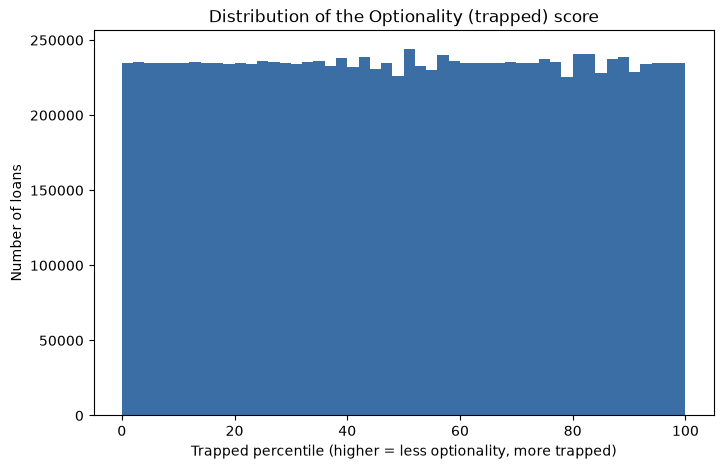

In [4]:
scored = opt.drop_nulls(subset=["equity_cushion", "rate_lock_severity"])

def zscore(col):
    m, s = scored[col].mean(), scored[col].std()
    return (pl.col(col) - m) / s

scored = scored.with_columns(
    # higher trapped_z = more trapped: low equity cushion (negative z), high rate lock, prior assistance used
    trapped_z=(
        -zscore("equity_cushion")
        + zscore("rate_lock_severity")
        + pl.col("prior_assistance").cast(pl.Float64)
    )
)
scored = scored.with_columns(
    optionality_trapped_pct=(pl.col("trapped_z").rank() / pl.len() * 100)
)

print(scored.select("equity_cushion", "rate_lock_severity", "prior_assistance", "optionality_trapped_pct").describe())

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(scored["optionality_trapped_pct"].to_numpy(), bins=50, color="#3b6ea5")
ax.set_xlabel("Trapped percentile (higher = less optionality, more trapped)")
ax.set_ylabel("Number of loans")
ax.set_title("Distribution of the Optionality (trapped) score")
plt.show()

# Research validation

**Question**: is rate-lock severity actually a stronger default predictor for loans that are genuinely locked in, versus loans where the theory shouldn't matter (their rate isn't meaningfully below market, so refinancing was never really an escape hatch they lost)?

Split into locked-in (`rate_lock_severity > 1.5` points -- their rate is at least 1.5pts below today's market) vs. not locked-in (`<= 1.5` points), and compare the standalone AUC of the three optionality components for predicting `default_target` within each group.

In [5]:
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline

scored_pd = scored.select(
    "equity_cushion", "rate_lock_severity", "prior_assistance", "default_target", "credit_score", "original_dti"
).to_pandas()

locked_in = scored_pd[scored_pd["rate_lock_severity"] > 1.5]
not_locked = scored_pd[scored_pd["rate_lock_severity"] <= 1.5]
print(f"Locked-in group: {len(locked_in):,} loans, default rate {locked_in['default_target'].mean():.4%}")
print(f"Not locked-in group: {len(not_locked):,} loans, default rate {not_locked['default_target'].mean():.4%}")
print()

def optionality_auc(df, label):
    X = df[["equity_cushion", "rate_lock_severity", "prior_assistance"]]
    y = df["default_target"]
    model = make_pipeline(SimpleImputer(strategy="median"), LogisticRegression(max_iter=1000, class_weight="balanced"))
    model.fit(X, y)
    proba = model.predict_proba(X)[:, 1]
    auc = roc_auc_score(y, proba)
    print(f"{label}: standalone optionality-only AUC = {auc:.4f}  (n={len(df):,})")
    return auc

auc_locked = optionality_auc(locked_in, "Locked-in loans   ")
auc_free = optionality_auc(not_locked, "Not locked-in loans")
print()
print(f"Difference (locked-in minus not-locked-in): {auc_locked - auc_free:+.4f}")

Locked-in group: 7,614,618 loans, default rate 2.0425%
Not locked-in group: 4,126,433 loans, default rate 1.8722%



Locked-in loans   : standalone optionality-only AUC = 0.9122  (n=7,614,618)


Not locked-in loans: standalone optionality-only AUC = 0.8151  (n=4,126,433)

Difference (locked-in minus not-locked-in): +0.0971


# Business output: the PD x Optionality quadrant ("sleeper risk")

Cross the existing PD model's prediction against the Optionality score. The interesting quadrant is **low PD, low optionality (highly trapped)** -- loans invisible to standard risk scoring today, but with no way to self-rescue if a shock hits.

shape: (4, 3)
┌─────────────────────────────────┬─────────┬──────────────┐
│ quadrant                        ┆ n_loans ┆ default_rate │
│ ---                             ┆ ---     ┆ ---          │
│ str                             ┆ u32     ┆ f64          │
╞═════════════════════════════════╪═════════╪══════════════╡
│ High risk + trapped (obvious d… ┆ 3122872 ┆ 0.04899      │
│ Genuinely safe                  ┆ 3089491 ┆ 0.003494     │
│ High risk, has options          ┆ 2772699 ┆ 0.012621     │
│ Sleeper risk (low PD, trapped)  ┆ 2755989 ┆ 0.012338     │
└─────────────────────────────────┴─────────┴──────────────┘

'Sleeper risk' population: 2,755,989 loans (23.47% of portfolio) -- low standard risk score, but structurally unable to self-rescue if a shock hits.


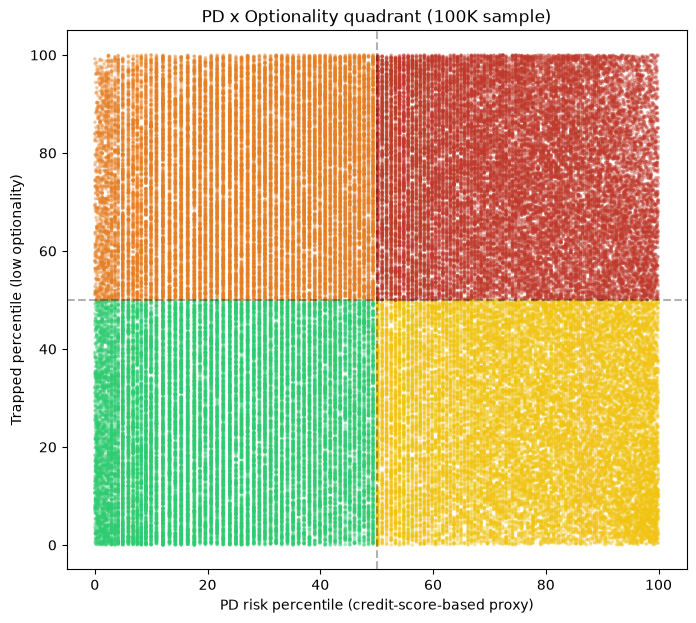

In [6]:
# Use credit_score as a simple, already-validated PD proxy (AUC 0.72 standalone, established earlier)
# rather than retraining the full 16-field model inside this notebook.
quad = scored.with_columns(
    pd_risk_pct=(pl.col("credit_score").rank(descending=True) / pl.len() * 100),  # low credit score -> high risk pct
).with_columns(
    quadrant=pl.when((pl.col("pd_risk_pct") <= 50) & (pl.col("optionality_trapped_pct") > 50))
        .then(pl.lit("Sleeper risk (low PD, trapped)"))
        .when((pl.col("pd_risk_pct") > 50) & (pl.col("optionality_trapped_pct") > 50))
        .then(pl.lit("High risk + trapped (obvious danger)"))
        .when((pl.col("pd_risk_pct") <= 50) & (pl.col("optionality_trapped_pct") <= 50))
        .then(pl.lit("Genuinely safe"))
        .otherwise(pl.lit("High risk, has options"))
)

summary = quad.group_by("quadrant").agg(
    n_loans=pl.len(),
    default_rate=pl.col("default_target").mean(),
).sort("n_loans", descending=True)
print(summary)

sleeper_count = quad.filter(pl.col("quadrant") == "Sleeper risk (low PD, trapped)").height
print(f"\n'Sleeper risk' population: {sleeper_count:,} loans ({sleeper_count/quad.height:.2%} of portfolio) -- "
      f"low standard risk score, but structurally unable to self-rescue if a shock hits.")

fig, ax = plt.subplots(figsize=(8, 7))
sample = quad.sample(n=100_000, seed=42).to_pandas()
colors = sample["quadrant"].map({
    "Genuinely safe": "#2ecc71",
    "High risk, has options": "#f1c40f",
    "Sleeper risk (low PD, trapped)": "#e67e22",
    "High risk + trapped (obvious danger)": "#c0392b",
})
ax.scatter(sample["pd_risk_pct"], sample["optionality_trapped_pct"], c=colors, s=3, alpha=0.3)
ax.axvline(50, color="k", linestyle="--", alpha=0.3)
ax.axhline(50, color="k", linestyle="--", alpha=0.3)
ax.set_xlabel("PD risk percentile (credit-score-based proxy)")
ax.set_ylabel("Trapped percentile (low optionality)")
ax.set_title("PD x Optionality quadrant (100K sample)")
plt.show()